Critical kLa ≈ 49.3 h⁻¹  (CL_min = 0.7560 mg/L ≥ KO1 = 0.25 mg/L)


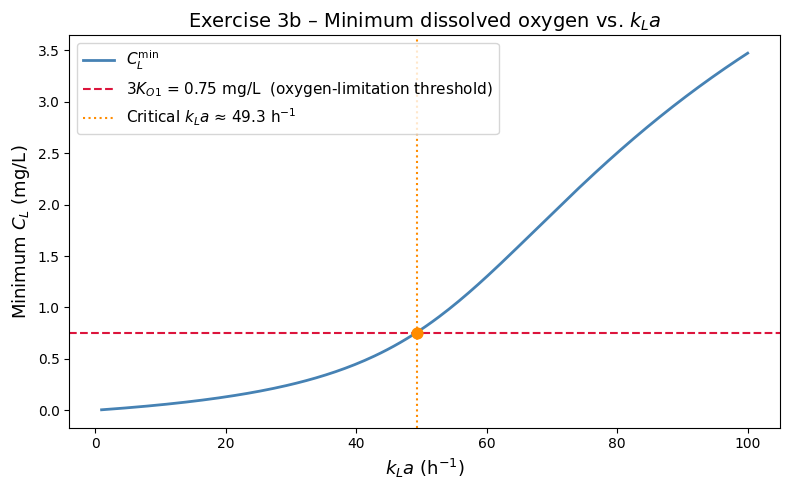

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ── Parameters ──────────────────────────────────────────────────────────────
vm1  = 125.0   # h-1
vm2  = 75.0    # h-1
K1   = 5.0     # mg/L
K2   = 3.0     # mg/L
KO1  = 0.25    # mg/L
KO2  = 0.5     # mg/L
YOS1 = 3.5     # mg O2 / mg S1
YOS2 = 1.1     # mg O2 / mg S2
CL_star = 8.0  # mg/L  (saturation)

# Initial conditions
S1_0 = 100.0   # mg/L  NH4+
S2_0 = 0.0     # mg/L  NO2-
S3_0 = 0.0     # mg/L  NO3-
CL_0 = 7.0     # mg/L  dissolved O2
y0   = [S1_0, S2_0, S3_0, CL_0]

t_span = (0, 5)          # hours – long enough to reach steady state
t_eval = np.linspace(*t_span, 2000)


# ── ODE system ───────────────────────────────────────────────────────────────
def system(t, y, kLa):
    S1, S2, S3, CL = y
    # Clip negatives to avoid numerical issues
    S1  = max(S1,  0.0)
    S2  = max(S2,  0.0)
    CL  = max(CL,  0.0)

    r1 = vm1 * (S1 / (K1 + S1)) * (CL / (KO1 + CL))
    r2 = vm2 * (S2 / (K2 + S2)) * (CL / (KO2 + CL))

    dS1 = -r1
    dS2 =  r1*YOS1/YOS2 - r2
    dS3 =  r2
    dCL =  kLa * (CL_star - CL) - YOS1 * r1 - YOS2 * r2

    return [dS1, dS2, dS3, dCL]


# ── Sweep kLa ────────────────────────────────────────────────────────────────
kLa_values = np.linspace(1, 100, 200)   # h-1
CL_min     = np.zeros_like(kLa_values)

for i, kLa in enumerate(kLa_values):
    sol = solve_ivp(system, t_span, y0, args=(kLa,),
                    method='BDF', rtol=1e-6, atol=1e-6,
                    t_eval=t_eval, dense_output=False)
    CL_min[i] = np.min(sol.y[3])   # row 3 = CL


# ── Find critical kLa (first value where CL_min >= KO1) ──────────────────────
idx_critical = np.where(CL_min >= 3 * KO1)[0]
if len(idx_critical) > 0:
    kLa_critical = kLa_values[idx_critical[0]]
    print(f"Critical kLa ≈ {kLa_critical:.1f} h⁻¹  "
          f"(CL_min = {CL_min[idx_critical[0]]:.4f} mg/L ≥ KO1 = {KO1} mg/L)")
else:
    print("No kLa in the tested range keeps CL above KO1.")
    kLa_critical = None


# ── Plot CL_min vs kLa ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(kLa_values, CL_min, color='steelblue', lw=2, label=r'$C_L^{\min}$')
ax.axhline(3 * KO1, color='crimson', ls='--', lw=1.5,
           label=rf'$3K_{{O1}}$ = {3*KO1} mg/L  (oxygen-limitation threshold)')

if kLa_critical is not None:
    ax.axvline(kLa_critical, color='darkorange', ls=':', lw=1.5,
               label=rf'Critical $k_La$ ≈ {kLa_critical:.1f} h$^{{-1}}$')
    ax.scatter([kLa_critical], [CL_min[idx_critical[0]]],
               color='darkorange', zorder=5, s=60)

ax.set_xlabel(r'$k_La$ (h$^{-1}$)', fontsize=13)
ax.set_ylabel(r'Minimum $C_L$ (mg/L)', fontsize=13)
ax.set_title('Exercise 3b – Minimum dissolved oxygen vs. $k_La$', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/exercise3b_plot.png', dpi=150)
plt.show()

S1 (NH4+) reaches ~0 mg/L at t ≈ 1.0088 h  (no oxygen limitation)


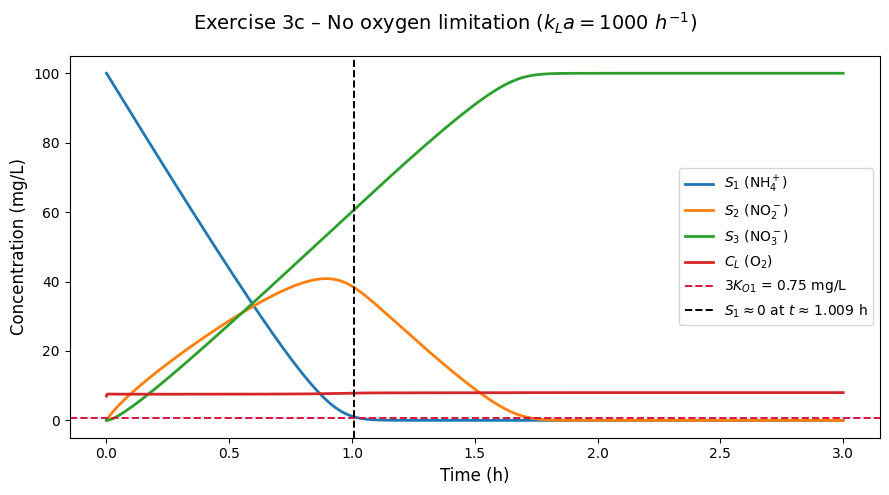

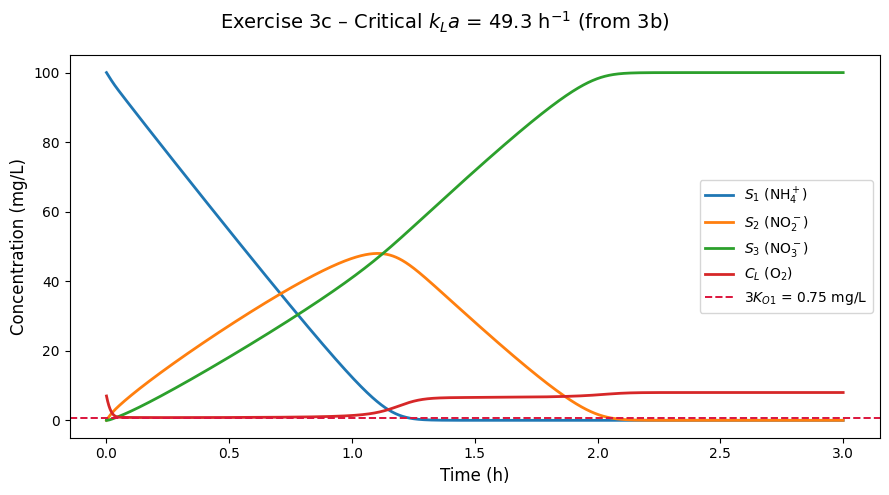

Plots saved.


In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ── Parameters ──────────────────────────────────────────────────────────────
vm1  = 125.0   # h-1
vm2  = 75.0    # h-1
K1   = 5.0     # mg/L
K2   = 3.0     # mg/L
KO1  = 0.25    # mg/L
KO2  = 0.5     # mg/L
YOS1 = 3.5     # mg O2 / mg S1
YOS2 = 1.1     # mg O2 / mg S2
CL_star = 8.0  # mg/L

# kLa values
kLa_no_lim  = 1000.0   # virtually no oxygen limitation
kLa_crit    = 49.3     # critical value found in 3b

# Initial conditions
y0 = [100.0, 0.0, 0.0, 7.0]   # S1, S2, S3, CL  [mg/L]

t_span = (0, 3)
t_eval = np.linspace(*t_span, 5000)


# ── ODE system ───────────────────────────────────────────────────────────────
def system(t, y, kLa):
    S1, S2, S3, CL = y
    S1 = max(S1, 0.0)
    S2 = max(S2, 0.0)
    CL = max(CL, 0.0)

    r1 = vm1 * (S1 / (K1 + S1)) * (CL / (KO1 + CL))
    r2 = vm2 * (S2 / (K2 + S2)) * (CL / (KO2 + CL))

    return [-r1,
             r1 - r2,
             r2,
             kLa * (CL_star - CL) - YOS1 * r1 - YOS2 * r2]


# ── Solve for both kLa values ─────────────────────────────────────────────────
sol_nl = solve_ivp(system, t_span, y0, args=(kLa_no_lim,),
                   method='BDF', rtol=1e-6, atol=1e-6, t_eval=t_eval)

sol_cr = solve_ivp(system, t_span, y0, args=(kLa_crit,),
                   method='BDF', rtol=1e-6, atol=1e-6, t_eval=t_eval)


# ── Find time when S1 → 0 (no-limitation case) ───────────────────────────────
threshold = 1.0   # mg/L  (consider "depleted" below this)
idx_zero = np.where(sol_nl.y[0] < threshold)[0]
if len(idx_zero) > 0:
    t_zero = sol_nl.t[idx_zero[0]]
    print(f"S1 (NH4+) reaches ~0 mg/L at t ≈ {t_zero:.4f} h  (no oxygen limitation)")
else:
    t_zero = None
    print("S1 did not reach 0 within the simulated time – extend t_span.")


# ── Figure 1 : no oxygen limitation (kLa = 1000) ─────────────────────────────
labels = [r'$S_1$ (NH$_4^+$)', r'$S_2$ (NO$_2^-$)',
          r'$S_3$ (NO$_3^-$)', r'$C_L$ (O$_2$)']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(r'Exercise 3c – No oxygen limitation ($k_La = 1000\ h^{-1}$)', fontsize=14)

for k, (lbl, col) in enumerate(zip(labels, colors)):
    ax.plot(sol_nl.t, sol_nl.y[k], color=col, lw=2, label=lbl)

ax.axhline(3 * KO1, color='crimson', ls='--', lw=1.4,
           label=rf'$3K_{{O1}}$ = {3*KO1} mg/L')
if t_zero is not None:
    ax.axvline(t_zero, color='black', ls='--', lw=1.4,
               label=rf'$S_1 \approx 0$ at $t$ ≈ {t_zero:.3f} h')

ax.set_xlabel('Time (h)', fontsize=12)
ax.set_ylabel('Concentration (mg/L)', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/exercise3c_no_limitation.png', dpi=150)
plt.show()


# ── Figure 2 : critical kLa from 3b ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(rf'Exercise 3c – Critical $k_La$ = {kLa_crit} h$^{{-1}}$ (from 3b)', fontsize=14)

for k, (lbl, col) in enumerate(zip(labels, colors)):
    ax.plot(sol_cr.t, sol_cr.y[k], color=col, lw=2, label=lbl)

ax.axhline(3 * KO1, color='crimson', ls='--', lw=1.4,
           label=rf'$3K_{{O1}}$ = {3*KO1} mg/L')

ax.set_xlabel('Time (h)', fontsize=12)
ax.set_ylabel('Concentration (mg/L)', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/exercise3c_critical_kLa.png', dpi=150)
plt.show()

print("Plots saved.")